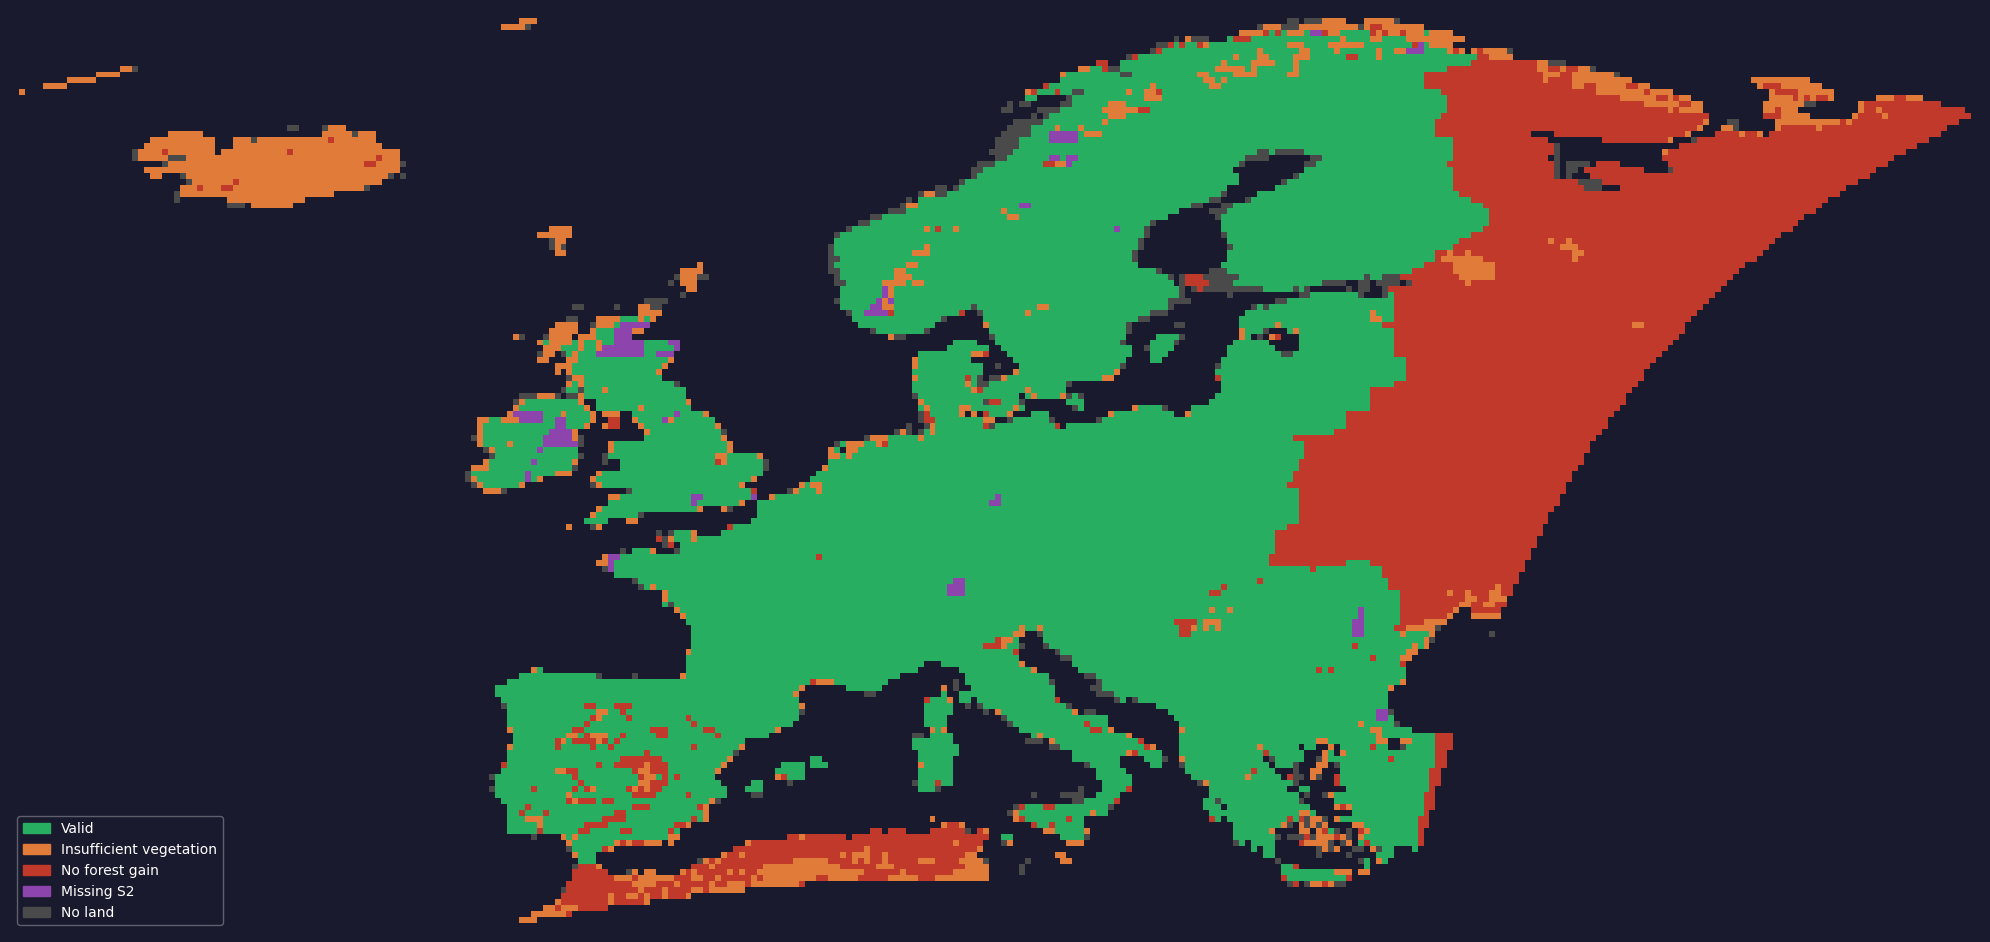

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

STEP = 0.25
CLIP_TO_DATA = True

lon_min = -180.0
lat_min = -60.0

lon_bins = int(360 / STEP)
lat_bins = int(145 / STEP)

# 0 = empty
# 1 = no_land
# 2 = insufficient_veg
# 3 = no_forest_gain
# 4 = missing_s2
# 5 = valid

grid = np.zeros((lat_bins, lon_bins), dtype=np.uint8)

REJECTION_CODE = {
    "no_land": 1,
    "insufficient_veg": 2,
    "no_forest_gain": 3,
    "missing_s2": 4,
    "valid": 5,
}


def get_props(a):
    return a.get("properties", a)


def add_to_grid(aois):
    for a in aois:
        p = get_props(a)

        min_lon = p.get("minLon")
        max_lon = p.get("maxLon")
        min_lat = p.get("minLat")
        max_lat = p.get("maxLat")
        reason = p.get("rejection_reason", "")

        if None in (min_lon, max_lon, min_lat, max_lat):
            continue

        code = REJECTION_CODE.get(reason, 0)
        if code == 0:
            continue

        lon = (min_lon + max_lon) / 2
        lat = (min_lat + max_lat) / 2

        x = int((lon - lon_min) / STEP)
        y = int((lat - lat_min) / STEP)

        if 0 <= x < lon_bins and 0 <= y < lat_bins:
            grid[y, x] = code


with open("data/aois/valid_aois.json") as f:
    valid_aois = json.load(f)

with open("data/aois/rejected_aois.json") as f:
    rejected_aois = json.load(f)

add_to_grid(rejected_aois)
add_to_grid(valid_aois)

colors = [
    "#1a1a2e",  # 0 empty
    "#4a4a4a",  # 1 no_land
    "#e07b39",  # 2 insufficient_veg
    "#c0392b",  # 3 no_forest_gain
    "#8e44ad",  # 4 missing_s2
    "#27ae60",  # 5 valid
]

cmap = ListedColormap(colors)

plt.figure(figsize=(20, 10), facecolor="#1a1a2e")
ax = plt.gca()
ax.set_facecolor("#1a1a2e")

ax.imshow(
    grid,
    origin="lower",
    interpolation="nearest",
    cmap=cmap,
    vmin=0,
    vmax=5,
)

legend_elements = [
    mpatches.Patch(color="#27ae60", label="Valid"),
    mpatches.Patch(color="#e07b39", label="Insufficient vegetation"),
    mpatches.Patch(color="#c0392b", label="No forest gain"),
    mpatches.Patch(color="#8e44ad", label="Missing S2"),
    mpatches.Patch(color="#4a4a4a", label="No land"),
]

ax.legend(
    handles=legend_elements,
    loc="lower left",
    framealpha=0.3,
    facecolor="#1a1a2e",
    edgecolor="white",
    labelcolor="white",
    fontsize=10,
)

if CLIP_TO_DATA:
    with open("data/aois/all_aois.json") as f:
        all_aois = json.load(f)
    all_aois = [a.get("properties", a) for a in all_aois]
    lons = [a["minLon"] for a in all_aois]
    lats = [a["minLat"] for a in all_aois]
    x_min = int((min(lons) - lon_min) / STEP) - 2
    x_max = int((max(lons) - lon_min) / STEP) + 2
    y_min = int((min(lats) - lat_min) / STEP) - 2
    y_max = int((max(lats) - lat_min) / STEP) + 2
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

ax.axis("off")
plt.tight_layout()
plt.savefig("data/aois/aoi_map.png", dpi=150, bbox_inches="tight", facecolor="#1a1a2e")
plt.show()

In [9]:
import json
from pathlib import Path

BASE = Path("data/aois")

ALL_AOIS_FILE = BASE / "all_aois.json"
VALID_FILE = BASE / "valid_aois.json"
REJECTED_FILE = BASE / "rejected_aois.json"

CHECKPOINT_FILE = BASE / "aoi_filter_checkpoint.json"

with open(ALL_AOIS_FILE) as f:
    all_aois = json.load(f)

with open(VALID_FILE) as f:
    valid_aois = json.load(f)

with open(REJECTED_FILE) as f:
    rejected_aois = json.load(f)

all_ids = {
    a["properties"]["id"]
    for a in all_aois
}

valid_ids = {
    a["id"]
    for a in valid_aois
}

rejected_ids = {
    a["id"]
    for a in rejected_aois
}

done_ids = valid_ids | rejected_ids

missing_ids = all_ids - done_ids

checkpoint = {
    "valid": valid_aois,
    "rejected": rejected_aois,
}

with open(CHECKPOINT_FILE, "w") as f:
    json.dump(checkpoint, f)

print(f"All AOIs       : {len(all_ids):,}")
print(f"Valid AOIs     : {len(valid_ids):,}")
print(f"Rejected AOIs  : {len(rejected_ids):,}")
print(f"Done AOIs      : {len(done_ids):,}")
print(f"Missing AOIs   : {len(missing_ids):,}")

dupes = len(valid_ids) + len(rejected_ids) - len(done_ids)

print(f"Duplicate IDs  : {dupes:,}")

if dupes > 0:
    print("WARNING: duplicate AOI IDs detected")

print(f"\nCheckpoint written to:")
print(CHECKPOINT_FILE)

All AOIs       : 18,387
Valid AOIs     : 11,409
Rejected AOIs  : 6,978
Done AOIs      : 18,387
Missing AOIs   : 0
Duplicate IDs  : 0

Checkpoint written to:
data/aois/aoi_filter_checkpoint.json


In [13]:
import json
import statistics
from collections import Counter
from pathlib import Path


AOI_DIR = Path("data/aois")
VALID_PATH    = AOI_DIR / "valid_aois.json"
REJECTED_PATH = AOI_DIR / "rejected_aois.json"

def load(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path.resolve()}")
    with open(path) as f:
        return json.load(f)

def num_stats(values, label, unit=""):
    vals = [v for v in values if v is not None]
    if not vals:
        return {}
    vals_sorted = sorted(vals)
    n = len(vals)
    mean = sum(vals) / n
    med  = statistics.median(vals)
    sd   = statistics.stdev(vals) if n > 1 else 0
    return {
        "label": label,
        "unit":  unit,
        "n":     n,
        "min":   vals_sorted[0],
        "p25":   vals_sorted[int(n * 0.25)],
        "mean":  mean,
        "median":med,
        "p75":   vals_sorted[int(n * 0.75)],
        "max":   vals_sorted[-1],
        "stdev": sd,
    }

def fmt(v, decimals=4):
    if isinstance(v, float):
        return f"{v:>{12}.{decimals}f}"
    if isinstance(v, int):
        return f"{v:>12,}"
    return f"{str(v):>12}"

def print_stats(s):
    if not s:
        return
    unit_str = f" ({s['unit']})" if s['unit'] else ""
    print(f"\n  {s['label']}{unit_str}  [n={s['n']:,}]")
    print(f"    {'Min':<10} {fmt(s['min'])}")
    print(f"    {'P25':<10} {fmt(s['p25'])}")
    print(f"    {'Mean':<10} {fmt(s['mean'])}")
    print(f"    {'Median':<10} {fmt(s['median'])}")
    print(f"    {'P75':<10} {fmt(s['p75'])}")
    print(f"    {'Max':<10} {fmt(s['max'])}")
    print(f"    {'Std Dev':<10} {fmt(s['stdev'])}")

def section(title):
    width = 68
    print()
    print("=" * width)
    print(f"  {title}")
    print("=" * width)

def subsection(title):
    print(f"\n── {title} " + "─" * (60 - len(title)))

def pct(part, total):
    return 100 * part / total if total else 0

print("Loading data …", flush=True)
valid    = load(VALID_PATH)
rejected = load(REJECTED_PATH)
all_aois = valid + rejected

n_valid    = len(valid)
n_rejected = len(rejected)
n_total    = len(all_aois)

section("1. DATASET OVERVIEW")
print(f"\n  Total AOIs          : {n_total:>10,}")
print(f"  Valid               : {n_valid:>10,}  ({pct(n_valid,  n_total):.1f} %)")
print(f"  Rejected            : {n_rejected:>10,}  ({pct(n_rejected, n_total):.1f} %)")

section("2. REJECTION REASON BREAKDOWN")
reasons = Counter(r["rejection_reason"] for r in rejected)
print(f"\n  {'Reason':<25} {'Count':>10}  {'% of Rejected':>14}  {'% of Total':>10}")
print(f"  {'-'*25} {'-'*10}  {'-'*14}  {'-'*10}")
for reason, cnt in reasons.most_common():
    print(f"  {reason:<25} {cnt:>10,}  {pct(cnt, n_rejected):>13.1f}%  {pct(cnt, n_total):>9.1f}%")

section("3. GEOGRAPHIC COVERAGE")
for label, dataset in [("Valid AOIs", valid), ("Rejected AOIs", rejected), ("All AOIs", all_aois)]:
    lats = [r["centroid_lat"] for r in dataset]
    lons = [r["centroid_lon"] for r in dataset]
    subsection(label)
    print(f"    Latitude  range : {min(lats):>9.3f} → {max(lats):.3f}")
    print(f"    Longitude range : {min(lons):>9.3f} → {max(lons):.3f}")

section("4. REGIONAL DISTRIBUTION")
for label, dataset in [("Valid", valid), ("Rejected", rejected)]:
    subsection(label)
    regions = Counter(r.get("region", "Unknown") for r in dataset)
    n = len(dataset)
    print(f"  {'Region':<30} {'Count':>8}  {'%':>6}")
    print(f"  {'-'*30} {'-'*8}  {'-'*6}")
    for region, cnt in regions.most_common():
        print(f"  {region:<30} {cnt:>8,}  {pct(cnt,n):>5.1f}%")

section("5. BIOME DISTRIBUTION")
for label, dataset in [("Valid", valid), ("Rejected", rejected)]:
    subsection(label)
    biomes = Counter(r.get("biome_name", "Unknown") for r in dataset)
    n = len(dataset)
    print(f"  {'Biome':<45} {'Count':>8}  {'%':>6}")
    print(f"  {'-'*45} {'-'*8}  {'-'*6}")
    for biome, cnt in biomes.most_common():
        print(f"  {biome:<45} {cnt:>8,}  {pct(cnt,n):>5.1f}%")

section("6. NUMERIC STATISTICS — VALID AOIs")
numeric_fields = [
    ("aoi_area_km2",         "AOI Area",             "km²"),
    ("land_frac",            "Land Fraction",        "0-1"),
    ("veg_fraction",         "Vegetation Fraction",  "0-1"),
    ("forest_gain_frac",     "Forest Gain Fraction", "0-1"),
    ("forest_gain_pixels",   "Forest Gain Pixels",   "px"),
]
for field, label, unit in numeric_fields:
    vals = [r[field] for r in valid if field in r]
    print_stats(num_stats(vals, label, unit))

gain_areas_valid = [
    r["aoi_area_km2"] * r["forest_gain_frac"]
    for r in valid
]
print_stats(num_stats(gain_areas_valid, "Forest Gain Area", "km²"))

section("7. NUMERIC STATISTICS — REJECTED AOIs")
for field, label, unit in numeric_fields:
    vals = [r[field] for r in rejected if field in r]
    print_stats(num_stats(vals, label, unit))

gain_areas_rejected = [
    r["aoi_area_km2"] * r["forest_gain_frac"]
    for r in rejected
]
print_stats(num_stats(gain_areas_rejected, "Forest Gain Area", "km²"))

section("8. FOREST GAIN — VALID vs REJECTED COMPARISON")

def gain_stats(label, areas):
    total = sum(areas)
    count = len(areas)
    nonzero = sum(1 for a in areas if a > 0)

    subsection(label)
    print(f"    Total forest gain area : {total:>12,.2f} km²")
    print(f"    AOIs with any gain     : {nonzero:>12,}  ({pct(nonzero, count):.1f}%)")
    print(f"    Mean gain per AOI      : {(total / count if count else 0):>12.4f} km²")

gain_stats("Valid", gain_areas_valid)
gain_stats("Rejected", gain_areas_rejected)

print()
print("=" * 68)
print("  Done.")
print("=" * 68)
print()

Loading data …

  1. DATASET OVERVIEW

  Total AOIs          :     18,387
  Valid               :     11,409  (62.0 %)
  Rejected            :      6,978  (38.0 %)

  2. REJECTION REASON BREAKDOWN

  Reason                         Count   % of Rejected  % of Total
  ------------------------- ----------  --------------  ----------
  no_forest_gain                 4,892           70.1%       26.6%
  insufficient_veg               1,440           20.6%        7.8%
  no_land                          510            7.3%        2.8%
  missing_s2                       136            1.9%        0.7%

  3. GEOGRAPHIC COVERAGE

── Valid AOIs ──────────────────────────────────────────────────
    Latitude  range :    35.125 → 70.625
    Longitude range :   -10.375 → 32.125

── Rejected AOIs ───────────────────────────────────────────────
    Latitude  range :    33.375 → 71.125
    Longitude range :   -29.375 → 52.375

── All AOIs ────────────────────────────────────────────────────
    Latitude

In [26]:
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

AOI_DIR       = Path("data/aois")
VALID_PATH    = AOI_DIR / "valid_aois.json"
REJECTED_PATH = AOI_DIR / "rejected_aois.json"
OUT_DIR       = Path("dt_plots")
SCATTER_N     = 3000
RANDOM_SEED   = 42

OUT_DIR.mkdir(exist_ok=True)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#e6edf3",
    "grid.color":       "#21262d",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "legend.facecolor": "#1c2128",
    "legend.edgecolor": "#30363d",
    "font.family":      "monospace",
    "font.size":        10,
})

# Perceptually distinct, colourblind-safe (Wong 2011 + tweaks)
COLORS = {
    "valid":            "#2ecc71",   # vivid green
    "no_land":          "#3498db",   # blue
    "insufficient_veg": "#e67e22",   # orange
    "no_forest_gain":   "#e74c3c",   # red
    "missing_s2":       "#9b59b6",   # purple
}
REASON_LABELS = {
    "valid":            "Valid",
    "no_land":          "No Land",
    "insufficient_veg": "Insuff. Veg",
    "no_forest_gain":   "No Forest Gain",
    "missing_s2":       "Missing S2",
}
REASONS = ["valid", "no_land", "insufficient_veg", "no_forest_gain", "missing_s2"]

def threshold_vline(ax, x, label, color="#facc15", alpha=0.12, lw=1.8):
    ax.axvline(x, color=color, lw=lw, zorder=4)
    ax.axvspan(ax.get_xlim()[0], x, color=color, alpha=alpha, zorder=0)
    ymax = ax.get_ylim()[1]
    ax.text(x + (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.01, ymax * 0.96,
            label, color=color, fontsize=8, fontweight="bold", va="top", zorder=5)

def threshold_hline(ax, y, label, color="#facc15", alpha=0.12, lw=1.8):
    ax.axhline(y, color=color, lw=lw, zorder=4)
    ax.axhspan(ax.get_ylim()[0], y, color=color, alpha=alpha, zorder=0)
    xmax = ax.get_xlim()[1]
    ax.text(xmax * 0.01, y * 1.08, label, color=color,
            fontsize=8, fontweight="bold", va="bottom", zorder=5)

print("Loading data…")
with open(VALID_PATH) as f:
    valid = json.load(f)
with open(REJECTED_PATH) as f:
    rejected = json.load(f)

def compute_gain_area(r):
    return r.get("aoi_area_km2", 0) * r.get("forest_gain_frac", 0)

for r in valid:
    r["gain_area_km2"] = compute_gain_area(r)

for r in rejected:
    r["gain_area_km2"] = compute_gain_area(r)

all_aois = valid + rejected

MIN_LAT = min(r["centroid_lat"] for r in all_aois)
MAX_LAT = max(r["centroid_lat"] for r in all_aois)
MIN_LON = min(r["centroid_lon"] for r in all_aois)
MAX_LON = max(r["centroid_lon"] for r in all_aois)

CELL_SIZE = 0.25  # degrees

LAT_BINS = int(np.ceil((MAX_LAT - MIN_LAT) / CELL_SIZE))
LON_BINS = int(np.ceil((MAX_LON - MIN_LON) / CELL_SIZE))

n_valid, n_rejected, n_total = len(valid), len(rejected), len(all_aois)
print(f"  {n_valid:,} valid  |  {n_rejected:,} rejected  |  {n_total:,} total")

v_sample = random.sample(valid,    min(SCATTER_N, n_valid))
r_sample = random.sample(rejected, min(SCATTER_N, n_rejected))

def savefig(name):
    p = OUT_DIR / name
    plt.savefig(p, dpi=150, bbox_inches="tight", facecolor=plt.gcf().get_facecolor())
    plt.close()
    print(f"  → {p}")

skip = {"Unknown", "N/A"}

def short_biome(b):
    return (b.replace("Tropical & Subtropical ", "T&S ")
             .replace("Temperate ", "Temp. ")
             .replace(", Savannas & Shrublands", "/Sav")
             .replace("Grasslands", "Grass")
             .replace("Forests/Taiga", "Forests")
             .replace(" & Mixed Forests", "")
             .replace("Woodlands & Scrub", "Scrub")
             .replace("Deserts & Xeric Shrublands", "Deserts/Xeric")
             .replace("Flooded Grasslands & Savannas", "Flooded Grass")
             .replace("Montane Grasslands & Shrublands", "Montane Grass")
             .replace(" Forests", ""))

print("\n[1/11] Density heatmaps…")

def density_grid(records):
    grid = np.zeros((LAT_BINS, LON_BINS))

    for r in records:
        li = int((r["centroid_lat"] - MIN_LAT) / CELL_SIZE)
        lo = int((r["centroid_lon"] - MIN_LON) / CELL_SIZE)

        if 0 <= li < LAT_BINS and 0 <= lo < LON_BINS:
            grid[li, lo] += 1

    return grid

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("AOI Spatial Density  (0.25° cells)", color="#e6edf3", fontsize=13, y=1.01)

specs = [
    (valid,    "Valid AOIs",    ["#0d2a1a", "#2ecc71"]),
    (rejected, "Rejected AOIs", ["#2a0d0d", "#e74c3c"]),
]
for ax, (records, title, clrs) in zip(axes, specs):
    grid = density_grid(records)

    cmap = LinearSegmentedColormap.from_list("", clrs)

    used_rows = np.where(grid.sum(axis=1) > 0)[0]
    used_cols = np.where(grid.sum(axis=0) > 0)[0]

    if len(used_rows) == 0 or len(used_cols) == 0:
        continue

    min_row, max_row = used_rows[0], used_rows[-1]
    min_col, max_col = used_cols[0], used_cols[-1]

    cropped = grid[min_row:max_row + 1, min_col:max_col + 1]

    lat_min = MIN_LAT + min_row * CELL_SIZE
    lat_max = MIN_LAT + (max_row + 1) * CELL_SIZE
    lon_min = MIN_LON + min_col * CELL_SIZE
    lon_max = MIN_LON + (max_col + 1) * CELL_SIZE

    im = ax.imshow(
        cropped ** 0.4,
        extent=[lon_min, lon_max, lat_min, lat_max],
        origin="lower",
        aspect="auto",
        cmap=cmap,
        interpolation="nearest"
    )

    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Count (γ=0.4)")
    ax.set_title(title, color="#e6edf3", fontsize=11)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.grid(False)

plt.tight_layout()
savefig("01_density_heatmaps.png")

print("[2/11] Stacked bar by region…")

region_counts = defaultdict(Counter)
for r in all_aois:
    region_counts[r.get("region", "Unknown")][r.get("rejection_reason", "valid")] += 1

regions = [k for k in sorted(region_counts, key=lambda k: -sum(region_counts[k].values()))
           if k not in skip]

fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("Rejection Composition by Biogeographic Realm", color="#e6edf3", fontsize=12)
bottoms = np.zeros(len(regions))
for reason in REASONS:
    vals = np.array([(region_counts[r].get(reason, 0) / sum(region_counts[r].values()))
                     for r in regions])
    ax.bar(regions, vals, bottom=bottoms, color=COLORS[reason],
           label=REASON_LABELS[reason], width=0.6)
    bottoms += vals

ax.set_ylabel("Proportion"); ax.set_ylim(0, 1)
ax.set_xticklabels(regions, rotation=25, ha="right")
ax.legend(loc="upper right", fontsize=9)
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout()
savefig("02_stacked_bar_region.png")

print("[3/11] Stacked bar by biome…")

biome_counts = defaultdict(Counter)
for r in all_aois:
    biome_counts[r.get("biome_name", "Unknown")][r.get("rejection_reason", "valid")] += 1

biomes_all = [k for k in sorted(biome_counts, key=lambda k: -sum(biome_counts[k].values()))
              if k not in skip]

fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle("Rejection Composition by Biome", color="#e6edf3", fontsize=12)
bottoms = np.zeros(len(biomes_all))
for reason in REASONS:
    vals = np.array([(biome_counts[b].get(reason, 0) / sum(biome_counts[b].values()))
                     for b in biomes_all])
    ax.bar([short_biome(b) for b in biomes_all], vals, bottom=bottoms,
           color=COLORS[reason], label=REASON_LABELS[reason], width=0.6)
    bottoms += vals

ax.set_ylabel("Proportion"); ax.set_ylim(0, 1)
ax.set_xticklabels([short_biome(b) for b in biomes_all], rotation=35, ha="right", fontsize=8)
ax.legend(loc="upper right", fontsize=9)
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout()
savefig("03_stacked_bar_biome.png")

print("[4/11] Filter funnel…")

funnel = {
    "All AOIs":        n_total,
    "Has Land":        n_total - sum(1 for r in rejected if r.get("rejection_reason") == "no_land"),
    "Has Vegetation":  n_total - sum(1 for r in rejected if r.get("rejection_reason") in {"no_land", "insufficient_veg"}),
    "Has Forest Gain": n_total - sum(1 for r in rejected if r.get("rejection_reason") in {"no_land", "insufficient_veg", "no_forest_gain"}),
    "Has S2 (Valid)":  n_valid,
}
labels = list(funnel.keys())
values = list(funnel.values())

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("AOI Filter Stage Funnel", color="#e6edf3", fontsize=12)

cmap_f = LinearSegmentedColormap.from_list("", ["#3498db", "#2ecc71"])
colors_f = [cmap_f(i / (len(labels) - 1)) for i in range(len(labels))]

max_val = max(values)

# Reverse for top-to-bottom funnel
labels_r = labels[::-1]
values_r = values[::-1]
colors_r = colors_f[::-1]

# Center each bar
lefts = [(max_val - v) / 2 for v in values_r]

bars = ax.barh(
    labels_r,
    values_r,
    left=lefts,
    color=colors_r,
    height=0.7
)

# Put count + percentage inside each bar
for bar, v in zip(bars, values_r):
    pct = 100 * v / n_total

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        f"{v:,}\n({pct:.1f}%)",
        ha="center",
        va="center",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

ax.set_xlim(0, max_val)
ax.set_xlabel("AOI Count")

# Hide x-axis if you want a cleaner funnel look
ax.set_xticks([])

# Remove unnecessary spines
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.grid(False)

plt.tight_layout()
savefig("04_filter_funnel.png")

print("[5/11] Pairplot…")

PAIR_FIELDS = ["veg_fraction", "forest_gain_frac", "land_frac", "aoi_area_km2"]
PAIR_LABELS = ["Veg Fraction", "Gain Fraction", "Land Fraction", "AOI Area km²"]
N_PAIR = 800

vp = random.sample(v_sample, min(N_PAIR, len(v_sample)))
rp = random.sample(r_sample, min(N_PAIR, len(r_sample)))

def extract(records, fields):
    return np.array([[r.get(f, 0) for f in fields] for r in records])

Vmat = extract(vp, PAIR_FIELDS)
Rmat = extract(rp, PAIR_FIELDS)

n = len(PAIR_FIELDS)
fig, axes = plt.subplots(n, n, figsize=(12, 10))
fig.suptitle("Pairplot — Valid (green) vs Rejected (red)", color="#e6edf3", fontsize=12, y=1.01)

for i in range(n):
    for j in range(n):
        ax = axes[i][j]
        if i == j:
            ax.hist(Vmat[:, i], bins=30, color=COLORS["valid"], alpha=0.55, density=True)
            ax.hist(Rmat[:, i], bins=30, color=COLORS["no_forest_gain"], alpha=0.55, density=True)
        else:
            ax.scatter(Rmat[:, j], Rmat[:, i], c=COLORS["no_forest_gain"],
                       s=5, alpha=0.3, linewidths=0, rasterized=True)
            ax.scatter(Vmat[:, j], Vmat[:, i], c=COLORS["valid"],
                       s=5, alpha=0.4, linewidths=0, rasterized=True)

        if i == n - 1: ax.set_xlabel(PAIR_LABELS[j], fontsize=8)
        else:          ax.set_xticklabels([])
        if j == 0:     ax.set_ylabel(PAIR_LABELS[i], fontsize=8)
        else:          ax.set_yticklabels([])
        ax.tick_params(labelsize=7)

plt.tight_layout()
savefig("05_pairplot.png")

print("[6/11] Correlation heatmap…")

def gain_area(r):
    return r.get("aoi_area_km2", 0) * r.get("forest_gain_frac", 0)

NUM_FIELDS  = ["aoi_area_km2", "land_frac", "veg_fraction", "forest_gain_frac"]
SHORT_NAMES = ["aoi_area", "land_frac", "veg_frac", "gain_frac"]

corr_data = np.array([[r.get(f, 0) for f in NUM_FIELDS] for r in valid], dtype=float)

# add MANUAL gain area column
gain_vec = np.array([gain_area(r) for r in valid]).reshape(-1, 1)
corr_data = np.hstack([corr_data, gain_vec])
SHORT_NAMES.append("gain_area")

C = np.corrcoef(corr_data.T)

from scipy import stats as _stats
n_obs = len(valid)

def pval(r, n):
    if abs(r) >= 1:
        return 0.0
    t = r * np.sqrt((n - 2) / (1 - r**2))
    return 2 * _stats.t.sf(abs(t), df=n - 2)

n_f = len(SHORT_NAMES)

CELL = 90
fig_px = CELL * n_f
fig, ax = plt.subplots(figsize=(fig_px / 72 + 2, fig_px / 72 + 1.5))
fig.suptitle("Correlation Matrix — Valid AOIs", color="#e6edf3", fontsize=13)

cmap_corr = LinearSegmentedColormap.from_list(
    "corr",
    ["#e74c3c", "#8e1c14", "#161b22", "#1a4d2a", "#2ecc71"]
)

im = ax.imshow(C, cmap=cmap_corr, vmin=-1, vmax=1, aspect="equal")
cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
cbar.set_label("Pearson r", color="#c9d1d9")

for i in range(n_f):
    for j in range(n_f):
        r = C[i, j]
        p = pval(r, n_obs)
        star = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        txt_color = "#ffffff" if abs(r) > 0.35 else "#8b949e"

        ax.text(j, i, f"{r:.2f}",
                ha="center", va="center",
                fontsize=10, color=txt_color, fontweight="bold")

        if star and i != j:
            ax.text(j + 0.35, i - 0.32, star,
                    ha="right", va="top",
                    fontsize=7, color=txt_color)

ax.set_xticks(range(n_f))
ax.set_yticks(range(n_f))
ax.set_xticklabels(SHORT_NAMES, rotation=35, ha="right", fontsize=10)
ax.set_yticklabels(SHORT_NAMES, fontsize=10)

for x in np.arange(-0.5, n_f, 1):
    ax.axhline(x, color="#0d1117", lw=1.5)
    ax.axvline(x, color="#0d1117", lw=1.5)

ax.text(0, -1.2, "* p<0.05  ** p<0.01  *** p<0.001",
        fontsize=8, color="#8b949e", transform=ax.transData)

plt.tight_layout()
savefig("06_corr_matrix.png")

print("[7/11] Biome x region heatmap…")

REGIONS_ORDERED = sorted({r.get("region") for r in valid if r.get("region")})

biome_region = defaultdict(Counter)

for r in valid:
    b = r.get("biome_name", "Unknown")
    rg = r.get("region", "Unknown")
    if b not in skip and rg in REGIONS_ORDERED:
        biome_region[b][rg] += 1

biomes_hr = sorted(biome_region, key=lambda b: -sum(biome_region[b].values()))

matrix = np.array(
    [[biome_region[b].get(rg, 0) for rg in REGIONS_ORDERED]
     for b in biomes_hr],
    dtype=float
)

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Valid AOI Count — Biome × Region", color="#e6edf3", fontsize=12)

cmap_hr = LinearSegmentedColormap.from_list("", ["#161b22", "#3498db"])
im = ax.imshow(matrix ** 0.5, cmap=cmap_hr, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Count (γ=0.5)")

thresh = matrix.max() ** 0.5 * 0.5

for i, b in enumerate(biomes_hr):
    for j, rg in enumerate(REGIONS_ORDERED):
        v = int(matrix[i, j])
        if v > 0:
            tc = "#0d1117" if matrix[i, j] ** 0.5 > thresh else "#8b949e"
            ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=8, color=tc)

ax.set_xticks(range(len(REGIONS_ORDERED)))
ax.set_xticklabels(REGIONS_ORDERED, rotation=25, ha="right")
ax.set_yticks(range(len(biomes_hr)))
ax.set_yticklabels([short_biome(b) for b in biomes_hr], fontsize=9)

plt.tight_layout()
savefig("07_biome_region_heatmap.png")

print("[8/11] Cumulative forest gain by biome…")

biome_gain_total = Counter()

for r in valid:
    b = r.get("biome_name", "Unknown")
    if b not in skip:
        biome_gain_total[b] += gain_area(r)

sorted_bg = sorted(biome_gain_total.items(), key=lambda x: -x[1])

bg_labels = [short_biome(b) for b, _ in sorted_bg]
bg_vals   = [v for _, v in sorted_bg]

total_g = sum(bg_vals)
bg_cum = np.cumsum(bg_vals) / total_g * 100 if total_g > 0 else np.zeros_like(bg_vals)

fig, ax1 = plt.subplots(figsize=(14, 5))
fig.suptitle("Cumulative Forest Gain by Biome — Valid AOIs", color="#e6edf3", fontsize=12)

cmap_bg = LinearSegmentedColormap.from_list("", ["#2ecc71", "#0d2a1a"])
bar_colors = [cmap_bg(i / max(len(bg_labels) - 1, 1)) for i in range(len(bg_labels))]

ax1.bar(range(len(bg_labels)), bg_vals, color=bar_colors, width=0.65)
ax1.set_ylabel("Total Gain Area (km²)")
ax1.set_xticks(range(len(bg_labels)))
ax1.set_xticklabels(bg_labels, rotation=35, ha="right", fontsize=8)

ax2 = ax1.twinx()
ax2.plot(range(len(bg_labels)), bg_cum, color="#e67e22", lw=2, marker="o", ms=5)
ax2.axhline(80, color="#9b59b6", lw=1.8, ls="--")
ax2.set_ylabel("Cumulative %", color="#e67e22")
ax2.set_ylim(0, 105)

plt.tight_layout()
savefig("8_cumulative_gain_biome.png")

print("[9/11] Boxplot gain by biome…")

biome_gain_vals = defaultdict(list)

for r in valid:
    b = r.get("biome_name", "Unknown")
    if b not in skip:
        biome_gain_vals[b].append(gain_area(r))

biomes_bp = sorted(biome_gain_vals, key=lambda b: -np.median(biome_gain_vals[b]))
bp_data = [biome_gain_vals[b] for b in biomes_bp]

fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle("Forest Gain by Biome — Boxplot (valid AOIs)", color="#e6edf3", fontsize=12)

ax.boxplot(
    bp_data,
    positions=range(len(biomes_bp)),
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="#2ecc71", linewidth=2.5),
    boxprops=dict(facecolor="#1c2128", edgecolor="#3498db", linewidth=1.5),
    whiskerprops=dict(color="#8b949e"),
    capprops=dict(color="#8b949e"),
    widths=0.55
)

means_bp = [np.mean(d) for d in bp_data]
ax.scatter(range(len(biomes_bp)), means_bp, color="#e67e22", s=40, marker="D")

ax.set_ylim(bottom=0)
ax.grid(True, axis="y")

ax.set_xticks(range(len(biomes_bp)))
ax.set_xticklabels([short_biome(b) for b in biomes_bp], rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Forest Gain Area (km²)")

plt.tight_layout()
savefig("9_boxplot_gain_biome.png")

print("\n[10/11] Biome contribution plots…")
print("\n[11/11] Region contribution plots…")

def contribution_figure(groupby_field, title_suffix, filename, label_fn=None):
    if label_fn is None:
        label_fn = lambda x: x

    valid_count = Counter()
    rejected_count = Counter()

    valid_gain = Counter()
    rejected_gain = Counter()

    for r in valid:
        g = r.get(groupby_field, "Unknown")
        if g in skip:
            continue
        valid_count[g] += 1
        valid_gain[g] += gain_area(r)

    for r in rejected:
        g = r.get(groupby_field, "Unknown")
        if g in skip:
            continue
        rejected_count[g] += 1
        rejected_gain[g] += gain_area(r)

    all_groups = sorted(
        set(valid_count) | set(rejected_count),
        key=lambda g: -(valid_count[g] + rejected_count[g])
    )

    short_labels = [label_fn(g) for g in all_groups]

    v_vals = np.array([valid_count[g] for g in all_groups])
    r_vals = np.array([rejected_count[g] for g in all_groups])

    vg_vals = np.array([valid_gain[g] for g in all_groups])
    rg_vals = np.array([rejected_gain[g] for g in all_groups])

    total = v_vals + r_vals
    rej_rate = np.where(total > 0, r_vals / total * 100, 0)

    gain_total = vg_vals + rg_vals
    gain_retention = np.where(gain_total > 0, vg_vals / gain_total * 100, 0)

    x = np.arange(len(all_groups))

    fig, axes = plt.subplots(2, 2, figsize=(17, 10))
    fig.suptitle(f"AOI Contribution by {title_suffix}", color="#e6edf3", fontsize=13)

    ax = axes[0, 0]
    ax.bar(x, v_vals, color=COLORS["valid"], label="Valid", width=0.65)
    ax.bar(x, r_vals, bottom=v_vals, color=COLORS["no_forest_gain"], label="Rejected", width=0.65)

    ax.set_title("AOI Count — Valid vs Rejected", color="#e6edf3")
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, rotation=35, ha="right", fontsize=8)
    ax.legend()
    ax.grid(True, axis="y")

    ax = axes[0, 1]
    bars = ax.bar(x, rej_rate, color=[plt.cm.RdYlGn_r(v/100) for v in rej_rate], width=0.65)

    ax.set_title("Rejection Rate (%)", color="#e6edf3")
    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, rotation=35, ha="right", fontsize=8)

    for bar, val in zip(bars, rej_rate):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width()/2, val + 1,
                    f"{val:.0f}%", ha="center", fontsize=7, color="#e6edf3")

    ax.grid(True, axis="y")

    ax = axes[1, 0]
    ax.bar(x, vg_vals, color="#2ecc71", label="Valid Gain", width=0.65)
    ax.bar(x, rg_vals, bottom=vg_vals, color="#e74c3c", label="Rejected Gain", width=0.65)

    ax.set_title("Total Forest Gain Area", color="#e6edf3")
    ax.set_ylabel("Gain Area (km²)")
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, rotation=35, ha="right", fontsize=8)
    ax.legend()
    ax.grid(True, axis="y")

    total_valid_gain = vg_vals.sum()
    total_rejected_gain = rg_vals.sum()
    total_gain_all = total_valid_gain + total_rejected_gain

    pct_retained = 100 * total_valid_gain / total_gain_all if total_gain_all > 0 else 0

    ax.text(
        0.98, 0.98,
        f"Valid gain: {total_valid_gain:,.0f} km²\n"
        f"Rejected gain: {total_rejected_gain:,.0f} km²\n"
        f"Retained: {pct_retained:.1f}%",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        bbox=dict(facecolor="#161b22", edgecolor="#30363d", alpha=0.9)
    )

    ax = axes[1, 1]
    bars = ax.bar(x, gain_retention, color=[plt.cm.viridis(v/100) for v in gain_retention], width=0.65)

    ax.set_title("Gain Retention (%)", color="#e6edf3")
    ax.set_ylim(0, 100)
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, rotation=35, ha="right", fontsize=8)

    for bar, val in zip(bars, gain_retention):
        if val > 5:
            ax.text(bar.get_x() + bar.get_width()/2, val + 1,
                    f"{val:.0f}%", ha="center", fontsize=7, color="#e6edf3")

    ax.grid(True, axis="y")

    for ax in axes.flat:
        ax.tick_params(colors="#8b949e")

    plt.tight_layout()
    savefig(filename)


contribution_figure("biome_name", "Biome", "10_biome_contribution.png", short_biome)
contribution_figure("region", "Region", "11_region_contribution.png")

print(f"\nDone — plots saved to ./{OUT_DIR}/")

Loading data…
  11,409 valid  |  6,978 rejected  |  18,387 total

[1/11] Density heatmaps…
  → dt_plots/01_density_heatmaps.png
[2/11] Stacked bar by region…
  → dt_plots/02_stacked_bar_region.png
[3/11] Stacked bar by biome…
  → dt_plots/03_stacked_bar_biome.png
[4/11] Filter funnel…


/var/folders/hc/sfp4541124dgt_m7q89kkk5c0000gp/T/ipykernel_31142/3733399875.py:206: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(regions, rotation=25, ha="right")
/var/folders/hc/sfp4541124dgt_m7q89kkk5c0000gp/T/ipykernel_31142/3733399875.py:232: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([short_biome(b) for b in biomes_all], rotation=35, ha="right", fontsize=8)


  → dt_plots/04_filter_funnel.png
[5/11] Pairplot…
  → dt_plots/05_pairplot.png
[6/11] Correlation heatmap…
  → dt_plots/06_corr_matrix.png
[7/11] Biome x region heatmap…
  → dt_plots/07_biome_region_heatmap.png
[8/11] Cumulative forest gain by biome…
  → dt_plots/8_cumulative_gain_biome.png
[9/11] Boxplot gain by biome…
  → dt_plots/9_boxplot_gain_biome.png

[10/11] Biome contribution plots…

[11/11] Region contribution plots…


/var/folders/hc/sfp4541124dgt_m7q89kkk5c0000gp/T/ipykernel_31142/3733399875.py:582: RuntimeWarning: invalid value encountered in divide
  gain_retention = np.where(gain_total > 0, vg_vals / gain_total * 100, 0)


  → dt_plots/10_biome_contribution.png
  → dt_plots/11_region_contribution.png

Done — plots saved to ./dt_plots/


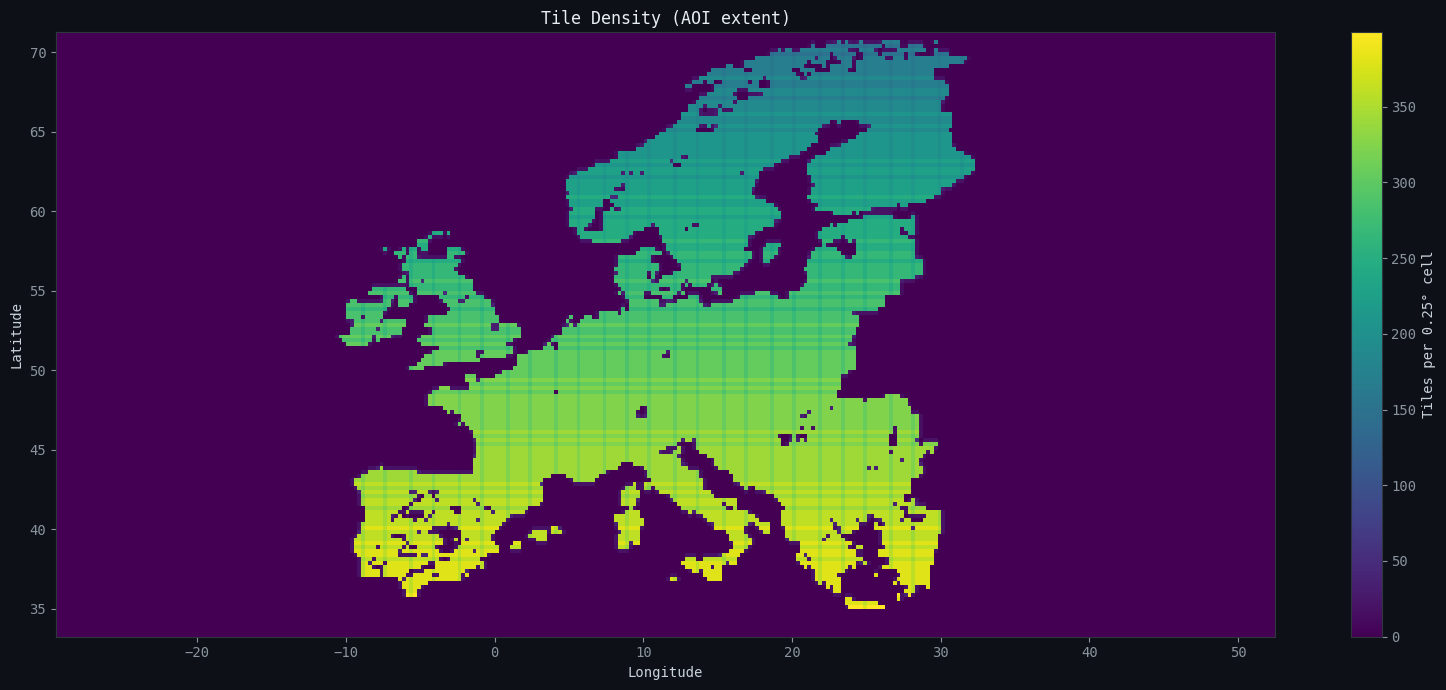

In [33]:
%matplotlib inline
import sqlite3
import numpy as np
import matplotlib.pyplot as plt

DB_PATH = "data/tiles/tile_registry.db"
RES = 0.25  # degrees per cell

conn = sqlite3.connect(DB_PATH)

query = f"""
SELECT
    CAST(((t.min_lon + t.max_lon) / 2 + 180) / {RES} AS INT) AS x_bin,
    CAST(((t.min_lat + t.max_lat) / 2 + 90) / {RES} AS INT) AS y_bin,
    COUNT(*) AS density
FROM tiles t
GROUP BY x_bin, y_bin
"""

rows = conn.execute(query).fetchall()
conn.close()

x_max = int(360 / RES)
y_max = int(180 / RES)

grid = np.zeros((y_max, x_max), dtype=np.int32)

for x, y, d in rows:
    if 0 <= x < x_max and 0 <= y < y_max:
        grid[y, x] = d

x0 = max(0, int(np.floor((MIN_LON + 180) / RES)))
x1 = min(x_max, int(np.ceil((MAX_LON + 180) / RES)))

y0 = max(0, int(np.floor((MIN_LAT + 90) / RES)))
y1 = min(y_max, int(np.ceil((MAX_LAT + 90) / RES)))

grid_crop = grid[y0:y1, x0:x1]

plot_lon_min = x0 * RES - 180
plot_lon_max = x1 * RES - 180
plot_lat_min = y0 * RES - 90
plot_lat_max = y1 * RES - 90

plt.figure(figsize=(16, 7))

plt.imshow(
    grid_crop,
    origin="lower",
    extent=[plot_lon_min, plot_lon_max, plot_lat_min, plot_lat_max],
    aspect="auto",
    interpolation="nearest",
)

plt.colorbar(label="Tiles per 0.25° cell")
plt.title("Tile Density (AOI extent)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

AOIs: 11409
Min: 144
Max: 420
Mean: 288.3109825576299
Median: 304.0


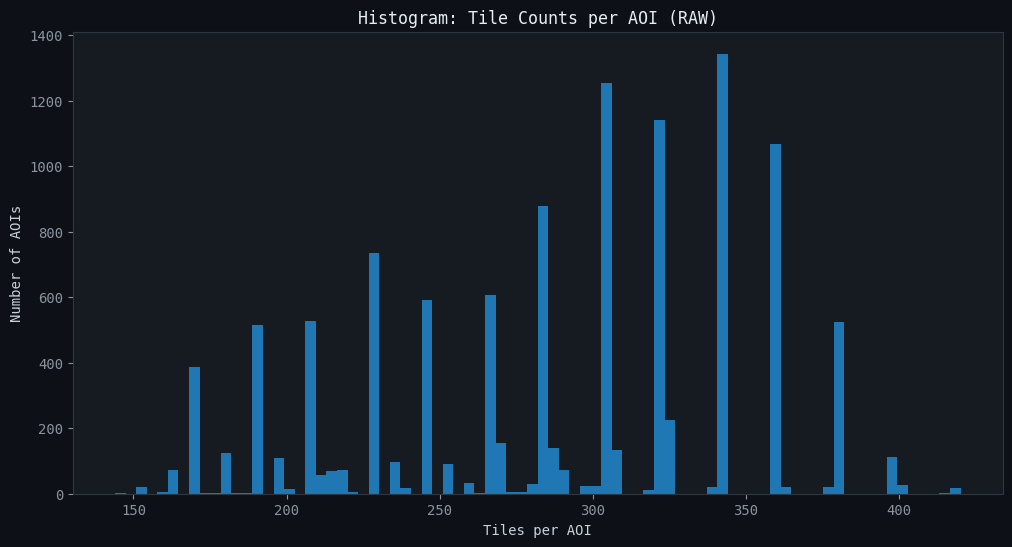

In [30]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt

DB_PATH = "data/tiles/tile_registry.db"

conn = sqlite3.connect(DB_PATH)

query = """
SELECT
    ta.aoi_id,
    COUNT(*) AS tile_count
FROM tile_aois ta
GROUP BY ta.aoi_id
"""

rows = conn.execute(query).fetchall()
conn.close()

tile_counts = np.array([r[1] for r in rows], dtype=np.int32)

print("AOIs:", len(tile_counts))
print("Min:", tile_counts.min())
print("Max:", tile_counts.max())
print("Mean:", tile_counts.mean())
print("Median:", np.median(tile_counts))

plt.figure(figsize=(12, 6))

plt.hist(tile_counts, bins=80)

plt.title("Histogram: Tile Counts per AOI (RAW)")
plt.xlabel("Tiles per AOI")
plt.ylabel("Number of AOIs")

plt.show()

AOIs: 11409
Raw mean tile count: 288.3109825576299
Corrected mean: 181.9631361995587


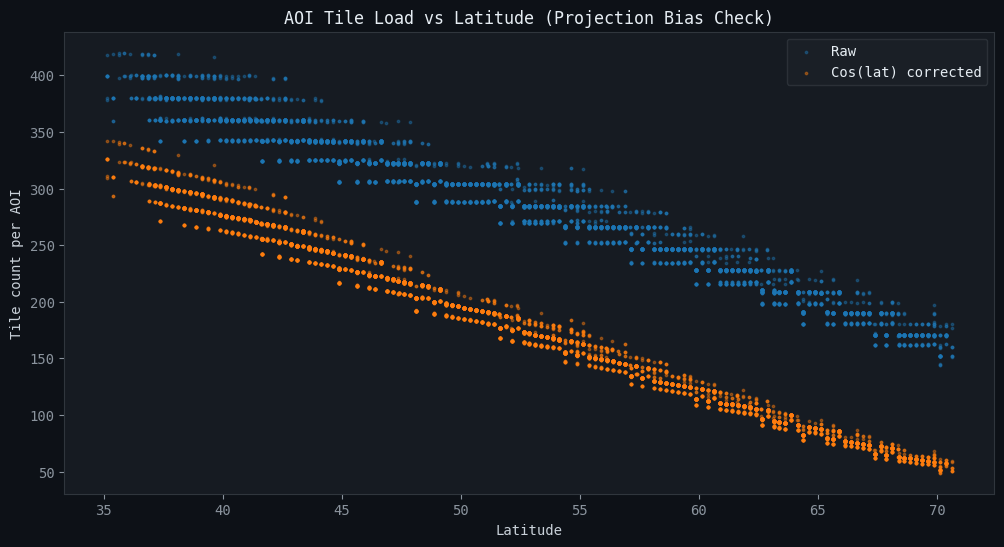

In [ ]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt

DB_PATH = "data/tiles/tile_registry.db"

conn = sqlite3.connect(DB_PATH)

query = """
SELECT
    ta.aoi_id,
    COUNT(*) AS tile_count,
    AVG((t.min_lat + t.max_lat) / 2.0) AS avg_lat
FROM tile_aois ta
JOIN tiles t ON t.tile_id = ta.tile_id
GROUP BY ta.aoi_id
"""

rows = conn.execute(query).fetchall()
conn.close()

tile_counts = np.array([r[1] for r in rows], dtype=np.float64)
avg_lats = np.array([r[2] for r in rows], dtype=np.float64)

# convert to radians
lat_rad = np.radians(avg_lats)

# Mercator correction factor
correction = np.cos(lat_rad)

normalized = tile_counts * correction

# diagnostics
print("AOIs:", len(tile_counts))
print("Raw mean tile count:", tile_counts.mean())
print("Corrected mean:", normalized.mean())

plt.figure(figsize=(12, 6))

plt.scatter(avg_lats, tile_counts, s=3, alpha=0.4, label="Raw")
plt.scatter(avg_lats, normalized, s=3, alpha=0.4, label="Cos(lat) corrected")

plt.title("AOI Tile Load vs Latitude (Projection Bias Check)")
plt.xlabel("Latitude")
plt.ylabel("Tile count per AOI")
plt.legend()

plt.show()

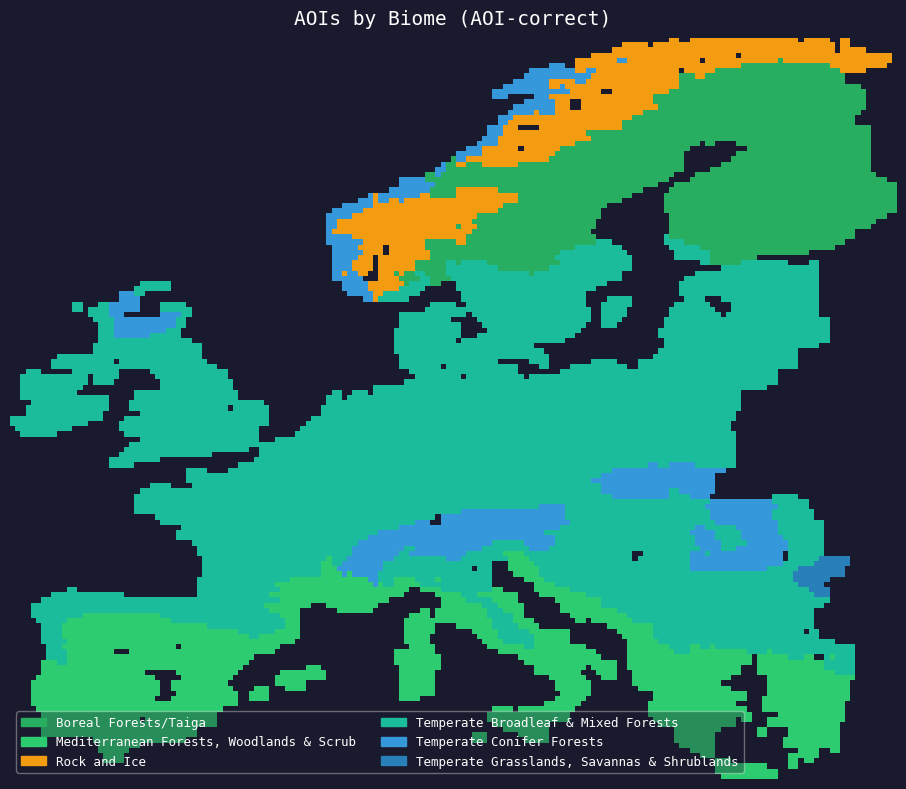

Saved → dt_plots/aoi_biome_map.png


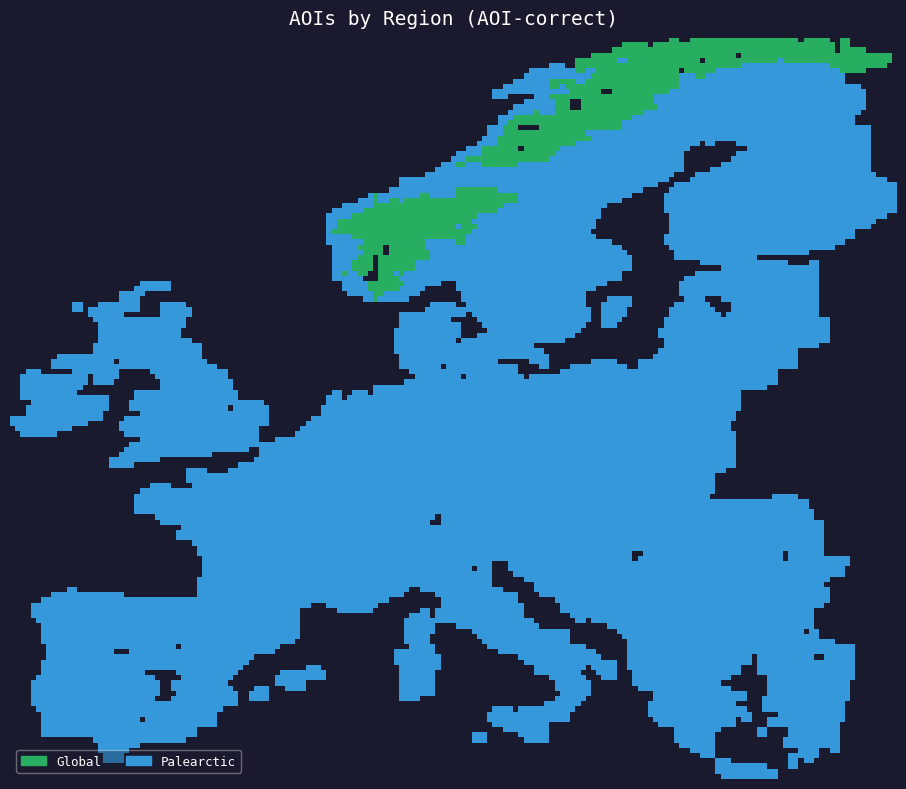

Saved → dt_plots/aoi_region_map.png


In [38]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

STEP = 0.25

with open("data/aois/valid_aois.json") as f:
    valid_aois = json.load(f)


def get_props(a):
    return a.get("properties", a)


# -----------------------------
# AOI EXTENT
# -----------------------------
min_lon = min(get_props(a).get("minLon") for a in valid_aois if get_props(a).get("minLon") is not None)
max_lon = max(get_props(a).get("maxLon") for a in valid_aois if get_props(a).get("maxLon") is not None)
min_lat = min(get_props(a).get("minLat") for a in valid_aois if get_props(a).get("minLat") is not None)
max_lat = max(get_props(a).get("maxLat") for a in valid_aois if get_props(a).get("maxLat") is not None)

lon_bins = int(np.ceil((max_lon - min_lon) / STEP))
lat_bins = int(np.ceil((max_lat - min_lat) / STEP))


biomes = sorted(set(
    get_props(a).get("biome_name", "Unknown")
    for a in valid_aois
    if get_props(a).get("biome_name") not in (None, "Unknown", "N/A")
))

regions = sorted(set(
    get_props(a).get("region", "Unknown")
    for a in valid_aois
    if get_props(a).get("region") not in (None, "Unknown", "N/A")
))

biome_to_idx = {b: i + 1 for i, b in enumerate(biomes)}
region_to_idx = {r: i + 1 for i, r in enumerate(regions)}

# IMPORTANT: categorical grids (NOT float accumulation)
biome_grid = np.zeros((lat_bins, lon_bins), dtype=np.uint8)
region_grid = np.zeros((lat_bins, lon_bins), dtype=np.uint8)


def clamp(v, lo, hi):
    return max(lo, min(hi, v))


# -----------------------------
# FILL GRID (FIXED LOGIC)
# -----------------------------
for a in valid_aois:
    p = get_props(a)

    min_lon_a = p.get("minLon")
    max_lon_a = p.get("maxLon")
    min_lat_a = p.get("minLat")
    max_lat_a = p.get("maxLat")

    if None in (min_lon_a, max_lon_a, min_lat_a, max_lat_a):
        continue

    biome = p.get("biome_name", "Unknown")
    region = p.get("region", "Unknown")

    x0 = int((min_lon_a - min_lon) / STEP)
    x1 = int((max_lon_a - min_lon) / STEP)
    y0 = int((min_lat_a - min_lat) / STEP)
    y1 = int((max_lat_a - min_lat) / STEP)

    x0, x1 = sorted((clamp(x0, 0, lon_bins - 1), clamp(x1, 0, lon_bins - 1)))
    y0, y1 = sorted((clamp(y0, 0, lat_bins - 1), clamp(y1, 0, lat_bins - 1)))

    # assign category (NOT +=)
    if biome in biome_to_idx:
        biome_grid[y0:y1+1, x0:x1+1] = biome_to_idx[biome]

    if region in region_to_idx:
        region_grid[y0:y1+1, x0:x1+1] = region_to_idx[region]


# -----------------------------
# COLORS
# -----------------------------
BIOME_COLORS = [
    "#1a1a2e","#27ae60","#2ecc71","#f39c12","#1abc9c",
    "#3498db","#2980b9","#e67e22","#d35400","#e74c3c",
    "#c0392b","#9b59b6","#8e44ad","#bdc3c7","#7f8c8d","#ffffff"
]

REGION_COLORS = [
    "#1a1a2e","#27ae60","#3498db","#e74c3c",
    "#f39c12","#9b59b6","#1abc9c","#e67e22","#bdc3c7"
]


def pad(colors, n):
    colors = list(colors)
    while len(colors) <= n:
        colors.append("#555555")
    return colors


biome_colors = pad(BIOME_COLORS, len(biomes))
region_colors = pad(REGION_COLORS, len(regions))


# -----------------------------
# PLOTTING
# -----------------------------
def save_map(grid, title, labels, colors, filename):
    fig, ax = plt.subplots(figsize=(18, 8), facecolor="#1a1a2e")
    ax.set_facecolor("#1a1a2e")

    ax.imshow(
        grid,
        origin="lower",
        interpolation="nearest",
        cmap=ListedColormap(colors[:len(labels) + 1]),
        vmin=0,
        vmax=len(labels)
    )

    ax.set_title(title, color="white", fontsize=14, pad=10)
    ax.axis("off")

    legend_elements = [
        mpatches.Patch(color=colors[i + 1], label=name)
        for i, name in enumerate(labels)
        if i + 1 < len(colors)
    ]

    ax.legend(
        handles=legend_elements,
        loc="lower left",
        framealpha=0.35,
        facecolor="#1a1a2e",
        edgecolor="white",
        labelcolor="white",
        fontsize=9,
        ncol=2,
    )

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight", facecolor="#1a1a2e")
    plt.show()
    plt.close()

    print(f"Saved → {filename}")


save_map(biome_grid, "AOIs by Biome (AOI-correct)", biomes, biome_colors,
         "dt_plots/aoi_biome_map.png")

save_map(region_grid, "AOIs by Region (AOI-correct)", regions, region_colors,
         "dt_plots/aoi_region_map.png")

In [ ]:
from osgeo import gdal
import os

YEAR = 2018
input_tif = f"../../../Downloads/tree_cover_{YEAR}.tif"
output_dir = f"../../../Downloads/tree_cover_{YEAR}_tiles"
os.makedirs(output_dir, exist_ok=True)

ds = gdal.Open(input_tif)
if ds is None:
    raise RuntimeError("Could not open input TIFF")

width = ds.RasterXSize
height = ds.RasterYSize

n = 4  # 4x4 grid
tile_w = width // n
tile_h = height // n

tile_id = 0

for row in range(n):
    for col in range(n):

        x_off = col * tile_w
        y_off = row * tile_h

        w = tile_w if col < n - 1 else (width - x_off)
        h = tile_h if row < n - 1 else (height - y_off)

        out_path = os.path.join(output_dir, f"tile_{tile_id:02d}.tif")

        print(f"Writing {out_path}")

        gdal.Translate(
            out_path,
            ds,
            srcWin=[x_off, y_off, w, h],
            format="GTiff",
            creationOptions=[
                "TILED=YES",
                "COMPRESS=DEFLATE",
                "ZLEVEL=1",
                "NUM_THREADS=ALL_CPUS",
                "BIGTIFF=YES"
            ]
        )

        tile_id += 1

ds = None

print(f"Done: {n*n} tiles created.")

Writing ../../../Downloads/tree_cover_2018_tiles/tile_00.tif
Done: 16 tiles created.
